In [1]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.decomposition import PCA
from google.colab import files

In [2]:
# 1. Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving Lab5.jpg to Lab5.jpg


In [3]:
# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [5]:
# 2. Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [12]:
# 3. Compute GLCM
glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

In [13]:
# 4. Extract Features
contrast = graycoprops(glcm, 'contrast')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

features = [contrast, correlation, energy, homogeneity]
labels = ['Contrast', 'Correlation', 'Energy', 'Homogeneity']

print("GLCM Features:")
for l, f in zip(labels, features):
    print(f"{l}: {f}")

GLCM Features:
Contrast: 10.542880743612185
Correlation: 0.9991679632819376
Energy: 0.027841014981155352
Homogeneity: 0.36453141470502903


In [14]:
# 5. Compute LBP
radius = 1
n_points = 8 * radius
lbp = local_binary_pattern(gray, n_points, radius, method='uniform')

In [15]:
# 6. Apply PCA
flat_gray = gray.flatten().reshape(-1, 1)
flat_lbp = lbp.flatten().reshape(-1, 1)

combined = np.hstack((flat_gray, flat_lbp))

pca = PCA(n_components=1)
pca_result = pca.fit_transform(combined)

In [16]:
# Normalize PCA result for display
pca_img = pca_result.reshape(gray.shape)
pca_img = cv2.normalize(pca_img, None, 0, 255, cv2.NORM_MINMAX)
pca_img = np.uint8(pca_img)

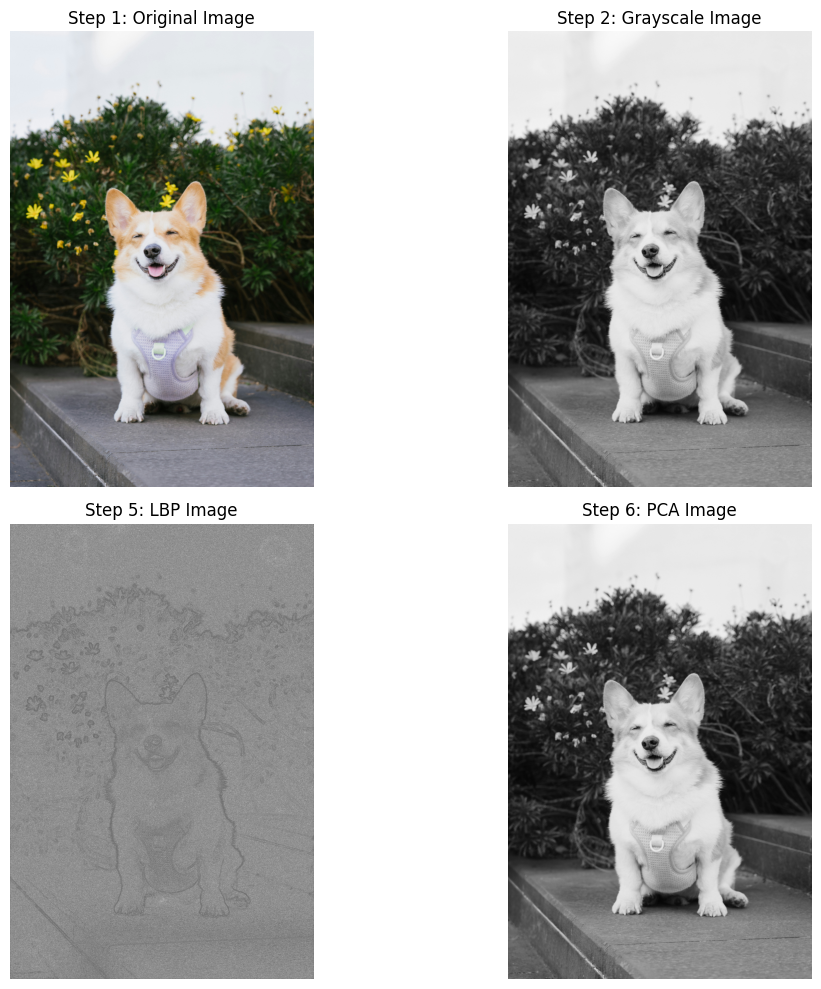

In [17]:
# Display images side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Step 1: Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title("Step 2: Grayscale Image")
axes[0, 1].axis('off')

axes[1, 0].imshow(lbp, cmap='gray')
axes[1, 0].set_title("Step 5: LBP Image")
axes[1, 0].axis('off')

axes[1, 1].imshow(pca_img, cmap='gray')
axes[1, 1].set_title("Step 6: PCA Image")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

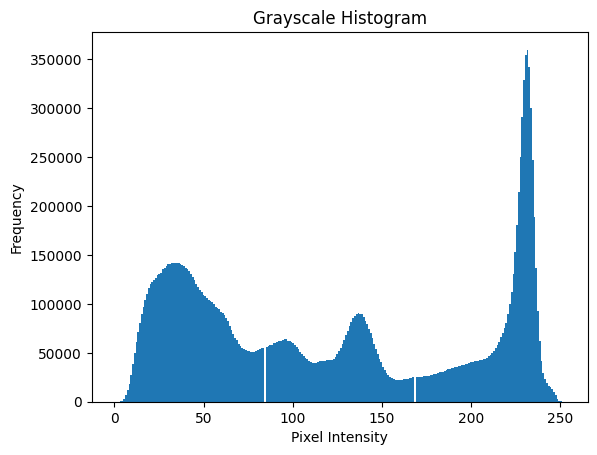

In [18]:
# Histogram of grayscale
plt.hist(gray.ravel(), bins=256)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

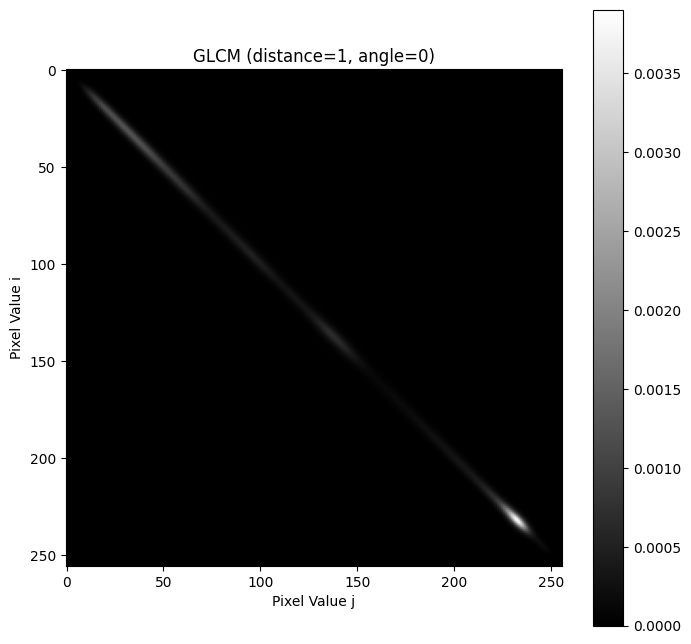

In [19]:
# Display GLCM as an image
plt.figure(figsize=(8, 8))
plt.imshow(glcm[:, :, 0, 0], cmap='gray')
plt.title("GLCM (distance=1, angle=0)")
plt.xlabel("Pixel Value j")
plt.ylabel("Pixel Value i")
plt.colorbar()
plt.show()

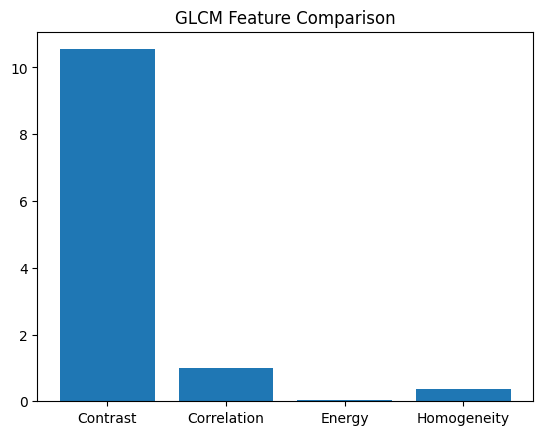

In [20]:
# Bar Graph for GLCM features
plt.bar(labels, features)
plt.title("GLCM Feature Comparison")
plt.show()

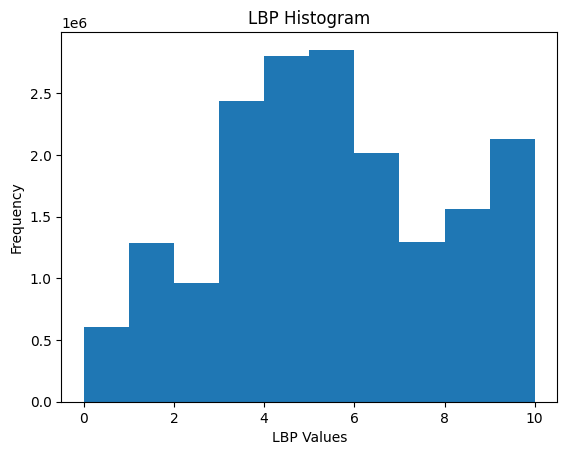

In [21]:
# LBP Histogram
plt.hist(lbp.ravel(), bins=np.arange(0, n_points + 3))
plt.title("LBP Histogram")
plt.xlabel("LBP Values")
plt.ylabel("Frequency")
plt.show()

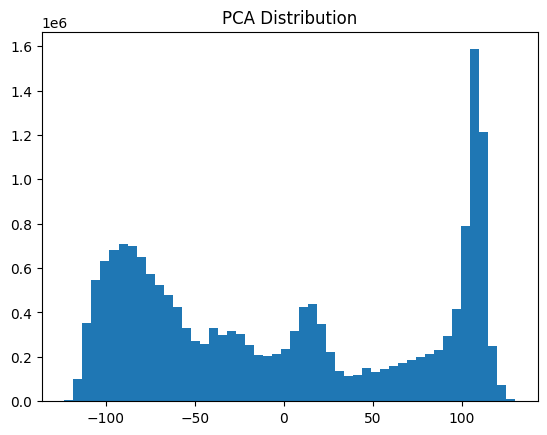

In [22]:
# PCA Histogram
plt.hist(pca_result, bins=50)
plt.title("PCA Distribution")
plt.show()

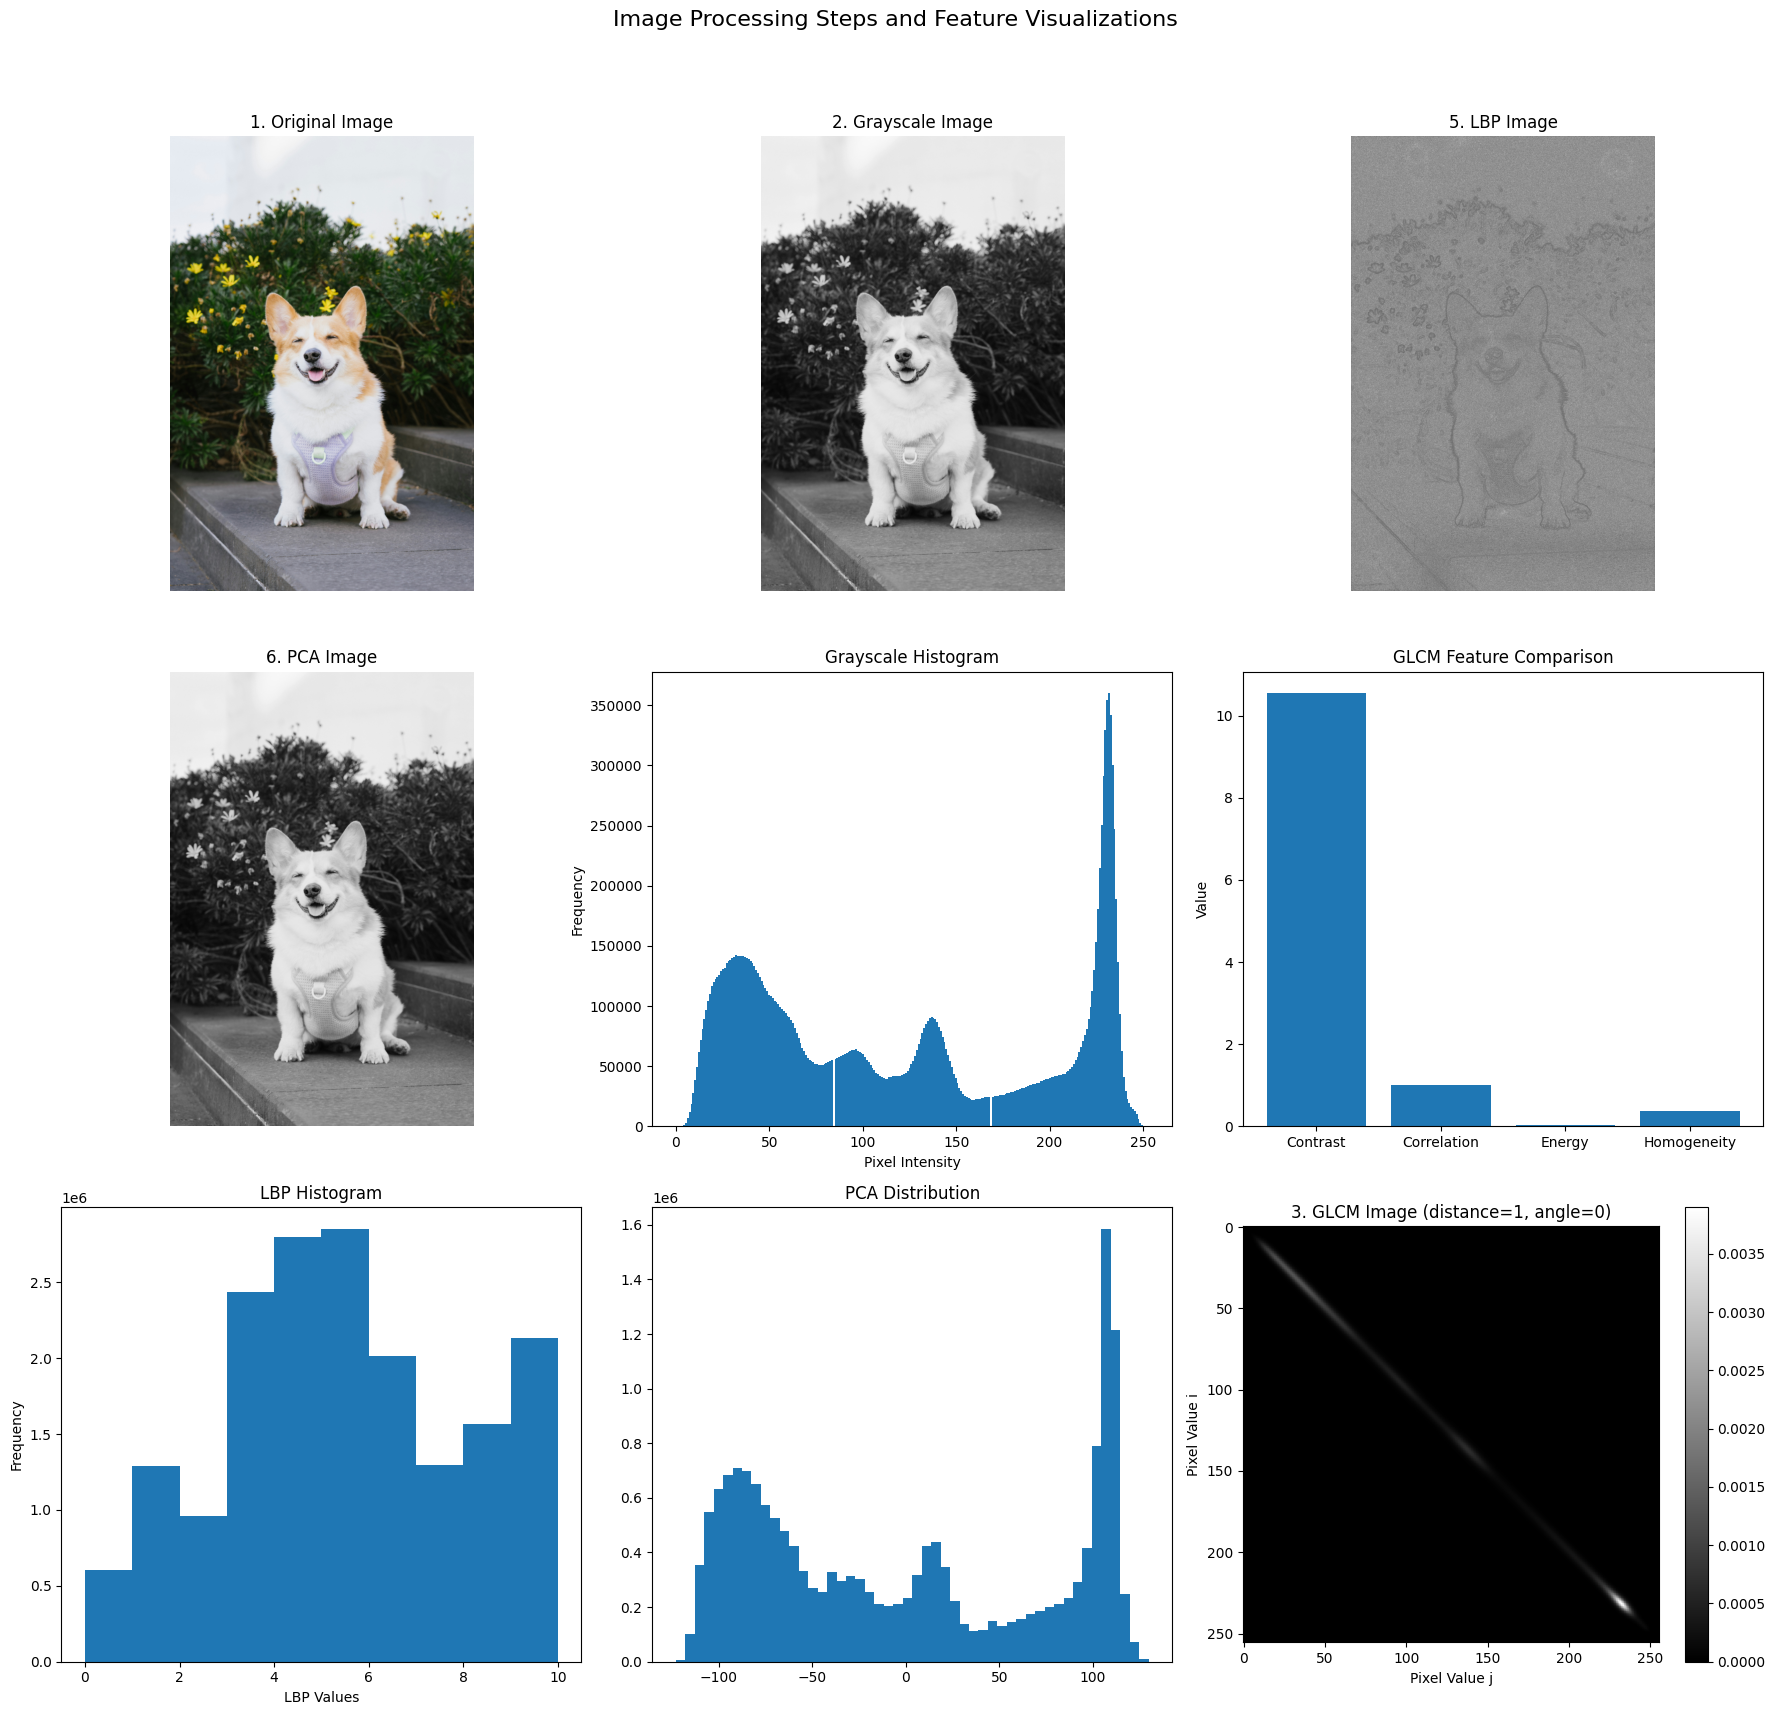

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Image Processing Steps and Feature Visualizations', fontsize=16)

# Plot 1: Original Image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Original Image")
axes[0, 0].axis('off')

# Plot 2: Grayscale Image
axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title("2. Grayscale Image")
axes[0, 1].axis('off')

# Plot 3: LBP Image
axes[0, 2].imshow(lbp, cmap='gray')
axes[0, 2].set_title("5. LBP Image")
axes[0, 2].axis('off')

# Plot 4: PCA Image
axes[1, 0].imshow(pca_img, cmap='gray')
axes[1, 0].set_title("6. PCA Image")
axes[1, 0].axis('off')

# Plot 5: Grayscale Histogram
axes[1, 1].hist(gray.ravel(), bins=256)
axes[1, 1].set_title("Grayscale Histogram")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")

# Plot 6: GLCM Features Bar Graph
axes[1, 2].bar(labels, features)
axes[1, 2].set_title("GLCM Feature Comparison")
axes[1, 2].set_ylabel("Value")

# Plot 7: LBP Histogram
axes[2, 0].hist(lbp.ravel(), bins=np.arange(0, n_points + 3))
axes[2, 0].set_title("LBP Histogram")
axes[2, 0].set_xlabel("LBP Values")
axes[2, 0].set_ylabel("Frequency")

# Plot 8: PCA Distribution
axes[2, 1].hist(pca_result, bins=50)
axes[2, 1].set_title("PCA Distribution")

# Plot 9: GLCM Image
axes[2, 2].imshow(glcm[:, :, 0, 0], cmap='gray')
axes[2, 2].set_title("3. GLCM Image (distance=1, angle=0)")
axes[2, 2].set_xlabel("Pixel Value j")
axes[2, 2].set_ylabel("Pixel Value i")
axes[2, 2].figure.colorbar(axes[2, 2].images[0], ax=axes[2, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()